# Running WOFOST for Miscanthus (WUR-field trial plot)
This notebook runs the PCSE/WOFOST model for Miscanthus using custom input data.

**Inputs:**
- Crop parameters: `miscanthus.yaml` (derived in `miscanthus_parameterization.ipynb`)
- Soil parameters: `soil_10110.soil` file (derived from Staringreeks 2018 via `soil_data_MvG.ipynb`)
- Weather data: `veenkampen_weather.xlsx` (MAQ station + AgERA5 gap-fill)
- Agromanagement: `misc_agro.yaml` (generated in parameterization notebook)
- Site parameters: defined inline below

In [96]:
%matplotlib inline
import sys
from pathlib import Path
import matplotlib
matplotlib.style.use("ggplot")
import matplotlib.pyplot as plt
import pandas as pd
import pcse
import numpy as np

print(f"Python version: {sys.version}")
print(f"PCSE version: {pcse.__version__}")

Python version: 3.13.12 | packaged by Anaconda, Inc. | (main, Feb 24 2026, 16:07:20) [Clang 20.1.8 ]
PCSE version: 6.0.12


## Define paths

In [97]:
# Project root
project = Path("/Users/paulianoprescu/Projects/wofost_miscanthus/miscanthus_calibration")
input_dir = project / "input_params"

crop_file    = input_dir / "miscanthus" / "miscanthus.yaml"
soil_file    = input_dir / "soil" / "soil_10110.soil"    
weather_file = input_dir / "weather" / "veenkampen_weather.xlsx"
agro_file    = input_dir / "agromanagement" / "misc_agro.yaml"

## Load crop parameters
Using `YAMLCropDataProvider` to read the Miscanthus YAML file generated in the parameterization notebook.

In [98]:
from pcse.input import YAMLCropDataProvider

cropdata = YAMLCropDataProvider(fpath=crop_file.parent, force_reload=True)
print(cropdata)

Crop parameters loaded from: /Users/paulianoprescu/Projects/wofost_miscanthus/miscanthus_calibration/input_params/miscanthus
Crop and variety not set: no active crop parameter set!



## Load soil parameters

In [99]:
from pcse.input import CABOFileReader

soildata = CABOFileReader(soil_file)
print(soildata)

** Generated from Bodemkaart van Nederland
** Profielcode: 10110
** Topsoil sfu: B02 (Staringreeks 2018)
** Generated by: generate_wofost_soil.py
**
** SOIL PARAMTER FILE for use in PCSE
**
------------------------------------
SMW: 0.074 <class 'float'>
SMFCF: 0.312 <class 'float'>
SM0: 0.434 <class 'float'>
CRAIRC: 0.09 <class 'float'>
K0: 83.242 <class 'float'>
SOPE: 83.24 <class 'float'>
KSUB: 22.32 <class 'float'>
SPADS: 0.8 <class 'float'>
SPODS: 0.04 <class 'float'>
SPASS: 0.9 <class 'float'>
SPOSS: 0.07 <class 'float'>
DEFLIM: 0.0 <class 'float'>
RDMSOL: 120 <class 'int'>
SOLNAM: 10110-B02 <class 'str'>
SMTAB: [-1.0, 0.434, 1.0, 0.421, 1.3, 0.405, 1.491, 0.388, 1.7, 0.361, 2.0, 0.312, 2.4, 0.244, 2.7, 0.198, 3.0, 0.161, 3.4, 0.123, 3.7, 0.101, 4.0, 0.083, 4.204, 0.074, 6.0, 0.033] <class 'list'>
CONTAB: [-1.0, 64.775, 1.0, 12.403, 1.3, 4.628, 1.491, 1.833, 1.7, 0.479, 2.0, 0.039, 2.4, 0.001, 2.7, 0.0, 3.0, 0.0, 3.4, 0.0, 3.7, 0.0, 4.0, 0.0, 4.204, 0.0, 6.0, 0.0] <class 'list'>



## Site parameters
These are not read from a file — they define initial conditions for the water balance and the atmospheric CO₂ concentration.

- **WAV**: Initial amount of water in total soil profile (cm). 70 cm is a reasonable assumption for a wet Dutch sandy soil.


In [100]:
from pcse.input import WOFOST72SiteDataProvider

sitedata = WOFOST72SiteDataProvider(WAV=70)
print(sitedata)

{'IFUNRN': 0, 'NOTINF': 0, 'SSI': 0.0, 'SSMAX': 0.0, 'WAV': 70.0, 'SMLIM': 0.4}


## Package all parameters

In [101]:
from pcse.base import ParameterProvider

parameters = ParameterProvider(cropdata=cropdata, soildata=soildata, sitedata=sitedata)

## Load weather data

In [102]:
from pcse.input import ExcelWeatherDataProvider

weatherdata = ExcelWeatherDataProvider(weather_file)
print(weatherdata)

Weather data provided by: ExcelWeatherDataProvider
--------Description---------
Weather data for:
Country: Netherlands
Station: Wageningen, Location Veenkampen
Description: Observed data from Station Veenkampen in Wageningen
Source: Meteorology and Air Quality Group, Wageningen University
Contact: None
----Site characteristics----
Elevation:    7.0
Latitude:  51.970
Longitude:  5.670
Data available for 2013-01-01 - 2026-01-01
Number of missing days: 0



## Load agromanagement

In [103]:
from pcse.input import YAMLAgroManagementReader

agromanagement = YAMLAgroManagementReader(agro_file)
print(agromanagement)

!!python/object/new:pcse.input.yaml_agro_loader.YAMLAgroManagementReader
listitems:
- 2015-01-01:
    CropCalendar:
      crop_end_date: 2015-12-30
      crop_end_type: maturity
      crop_name: miscanthus
      crop_start_date: 2015-01-01
      crop_start_type: emergence
      max_duration: 300
      variety_name: miscanthus_sinensis
    StateEvents: null
    TimedEvents: null
- 2016-01-01:
    CropCalendar:
      crop_end_date: 2016-12-30
      crop_end_type: maturity
      crop_name: miscanthus
      crop_start_date: 2016-01-01
      crop_start_type: emergence
      max_duration: 300
      variety_name: miscanthus_sinensis
    StateEvents: null
    TimedEvents: null
- 2017-01-01:
    CropCalendar:
      crop_end_date: 2017-12-30
      crop_end_type: maturity
      crop_name: miscanthus
      crop_start_date: 2017-01-01
      crop_start_type: emergence
      max_duration: 300
      variety_name: miscanthus_sinensis
    StateEvents: null
    TimedEvents: null
- 2018-01-01:
    CropCal

## Run simulation

In [104]:
from pcse.models import Wofost72_WLP_CWB, Wofost72_PP

# Potential Production Simulation
wofsim = Wofost72_PP(parameters, weatherdata, agromanagement)
wofsim.run_till_terminate()

df = pd.DataFrame(wofsim.get_output()).set_index("day")
print(f"Simulation period: {df.index[0]} to {df.index[-1]}")
print(f"Total rows: {len(df)}")
df.tail()

Simulation period: 2015-01-01 to 2025-01-01
Total rows: 3654


,DVS,LAI,TAGP,TWSO,TWLV,TWST,TWRT,TRA,RD,SM,WWLOW
day,,,,,,,,,,,
2024-12-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.312,None
2024-12-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.312,None
2024-12-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.312,None
2024-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.312,None
2025-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.312,None


## Visualize results
Four key output variables:
- **DVS**: Development stage (0 = emergence, 1 = anthesis, 2 = maturity)
- **TAGP**: Total above-ground production (kg/ha) 
- **LAI**: Leaf area index
- **SM**: Root-zone soil moisture (cm³/cm³)

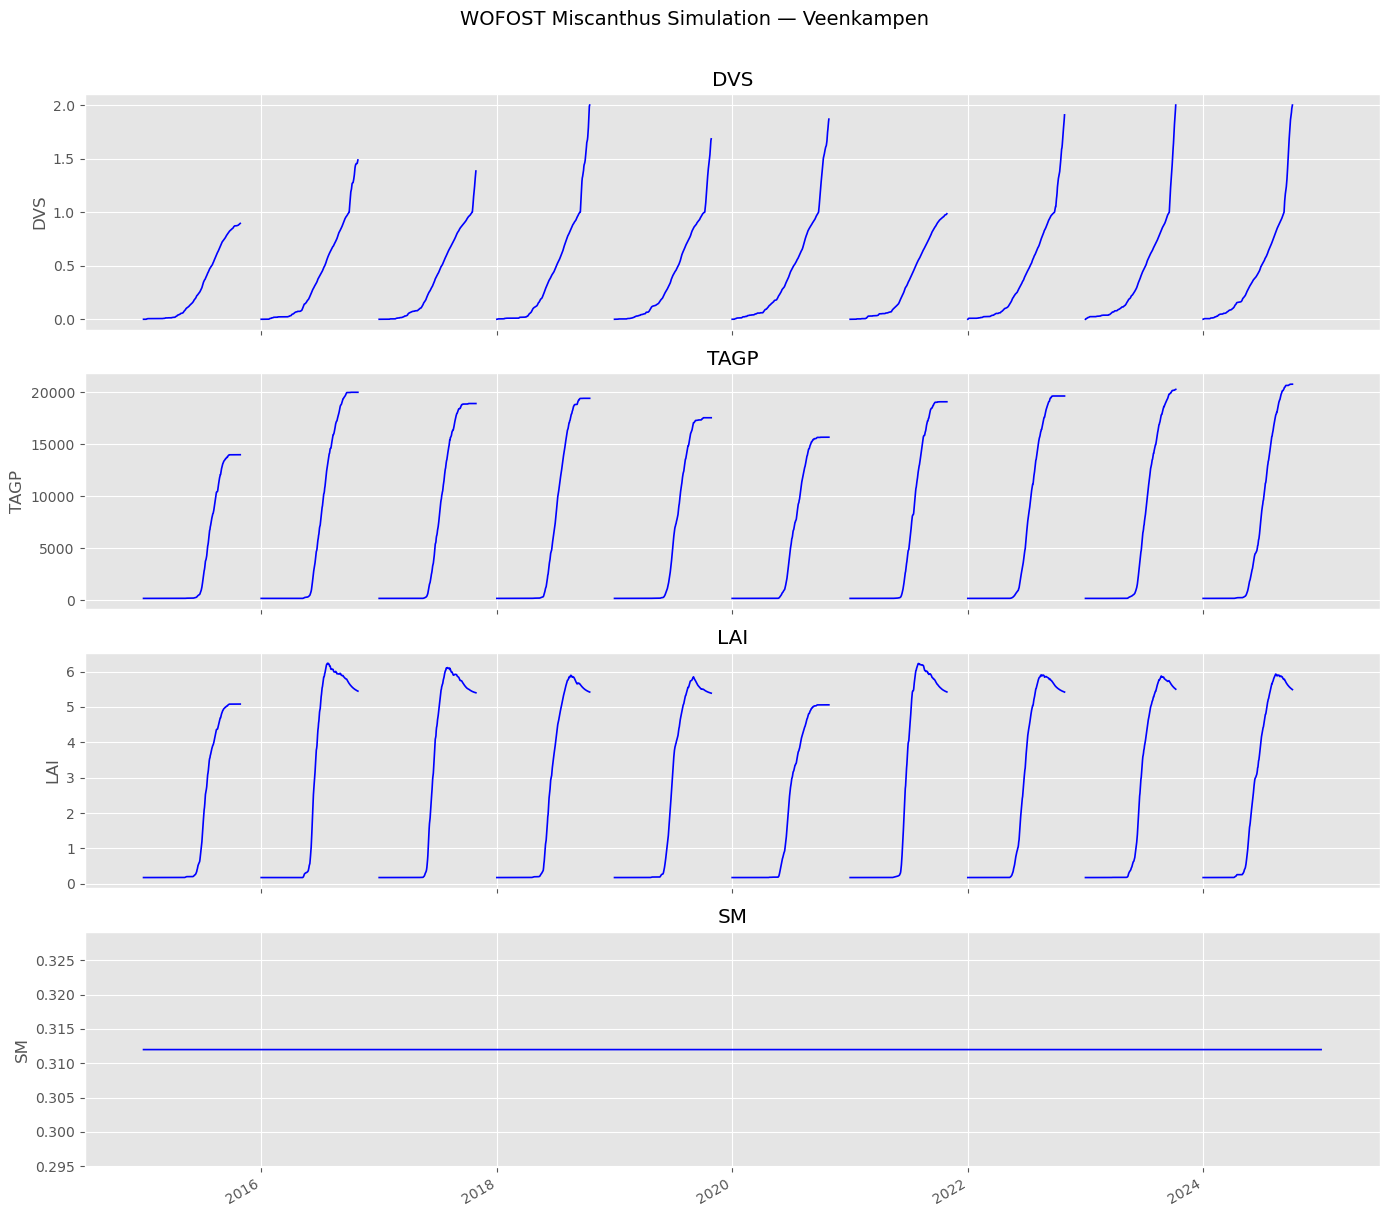

In [105]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)

for var, ax in zip(["DVS", "TAGP", "LAI", "SM"], axes.flatten()):
    ax.plot(df.index, df[var], "b-", linewidth=1.2)
    ax.set_ylabel(var)
    ax.set_title(var)

fig.suptitle("WOFOST Miscanthus Simulation — Veenkampen", fontsize=14, y=1.01)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Quick yield summary per year
Extract peak TAGP per growing season to compare against OD1302 observed yields.

In [106]:
# Group by year and get peak TAGP (= simulated yield at harvest)
df["year"] = df.index.map(lambda d: d.year)
yield_summary = df.groupby("year")["TAGP"].max().reset_index()
yield_summary.columns = ["Year", "Simulated_TAGP_kg_ha"]
yield_summary["Simulated_TAGP_t_ha"] = yield_summary["Simulated_TAGP_kg_ha"] / 1000

print(yield_summary.to_string(index=False))

 Year  Simulated_TAGP_kg_ha  Simulated_TAGP_t_ha
 2015          13989.776860            13.989777
 2016          19982.521178            19.982521
 2017          18904.024413            18.904024
 2018          19403.112879            19.403113
 2019          17539.496485            17.539496
 2020          15671.760330            15.671760
 2021          19072.985723            19.072986
 2022          19626.072787            19.626073
 2023          20262.352893            20.262353
 2024          20759.707844            20.759708
 2025                   NaN                  NaN


## Comparison

In [107]:
observed_yields = [11.24, 17.42, 15.33, 15.90, 12.99, 14.25, 11.02, np.nan, np.nan, 7.49, np.nan]
years_obs = list(range(2015, 2026))

# Create a dataframe with both
comparison = yield_summary.copy()
obs_dict = dict(zip(years_obs, observed_yields))
comparison["Observed_t_ha"] = comparison["Year"].map(obs_dict)

# Drop years with missing observations
comparison = comparison.dropna(subset=["Observed_t_ha"])

# Basic statistics
comparison["Error"] = comparison["Simulated_TAGP_t_ha"] - comparison["Observed_t_ha"]
rmse = np.sqrt((comparison["Error"] ** 2).mean())
mae = comparison["Error"].abs().mean()
bias = comparison["Error"].mean()
r = float(np.corrcoef(comparison["Observed_t_ha"], comparison["Simulated_TAGP_t_ha"])[0,1])

print(comparison[["Year", "Observed_t_ha", "Simulated_TAGP_t_ha", "Error"]].to_string(index=False))
print(f"\nRMSE:  {rmse:.2f} t/ha")
print(f"MAE:   {mae:.2f} t/ha")
print(f"Bias:  {bias:.2f} t/ha")
print(f"r:     {r:.3f}")
print(f"n:     {len(comparison)} years")

 Year  Observed_t_ha  Simulated_TAGP_t_ha     Error
 2015          11.24            13.989777  2.749777
 2016          17.42            19.982521  2.562521
 2017          15.33            18.904024  3.574024
 2018          15.90            19.403113  3.503113
 2019          12.99            17.539496  4.549496
 2020          14.25            15.671760  1.421760
 2021          11.02            19.072986  8.052986
 2024           7.49            20.759708 13.269708

RMSE:  6.15 t/ha
MAE:   4.96 t/ha
Bias:  4.96 t/ha
r:     0.029
n:     8 years


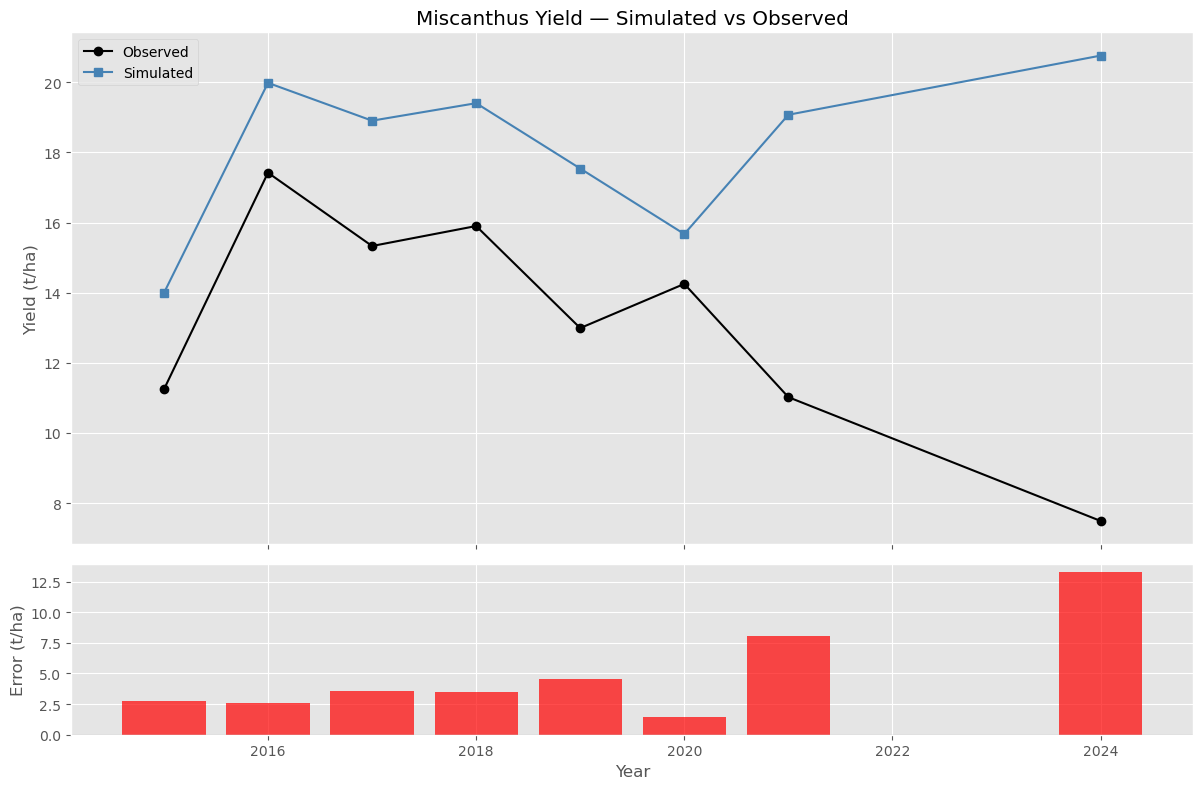

In [108]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

# Top panel: both lines
years = comparison["Year"]
ax1.plot(years, comparison["Observed_t_ha"], "o-", label="Observed", color="black")
ax1.plot(years, comparison["Simulated_TAGP_t_ha"], "s-", label="Simulated", color="steelblue")
ax1.set_ylabel("Yield (t/ha)")
ax1.set_title("Miscanthus Yield — Simulated vs Observed")
ax1.legend()

# Bottom panel: error bars
colors = ["green" if e < 0 else "red" for e in comparison["Error"]]
ax2.bar(years, comparison["Error"], color=colors, alpha=0.7)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Error (t/ha)")
ax2.set_xlabel("Year")

fig.tight_layout()